Import necessary libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

Step 1: Load the image

In [2]:
# Converted download link (from "view?usp=sharing")
image_url = "https://drive.google.com/uc?export=download&id=1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-"

context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

Step 2: Convert to Grayscale

    Harris detector requires a grayscale image to compute gradient and structure tensor.

        Formula: I(x, y) = 0.2989*R + 0.5870*G + 0.1140*B

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Convert to float32 for precision
gray_float = np.float32(gray)

Step 3: Apply Harris Corner Detection

    # Parameters: blockSize, ksize (Sobel aperture), k (Harris detector free parameter)

    Explanation:
          Harris Corner Score (R) = det(M) - k*(trace(M))^2
              # M is the second moment matrix (structure tensor) of gradients:
                  M = [ Ixx  Ixy ]
                      [ Ixy  Iyy ]
                              # where Ixx = Ix², Iyy = Iy², Ixy = IxIy


In [4]:
harris_response = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)


# Dilate to mark the corners more clearly
harris_dilated = cv2.dilate(harris_response, None)

# Threshold for local maxima
corner_threshold = 0.01 * harris_dilated.max()
corners = harris_dilated > corner_threshold

# Create color copy to mark corners
corner_image = image.copy()
corner_image[corners] = [0, 255, 0]  # Marking corners in green

Step 4: Visualization

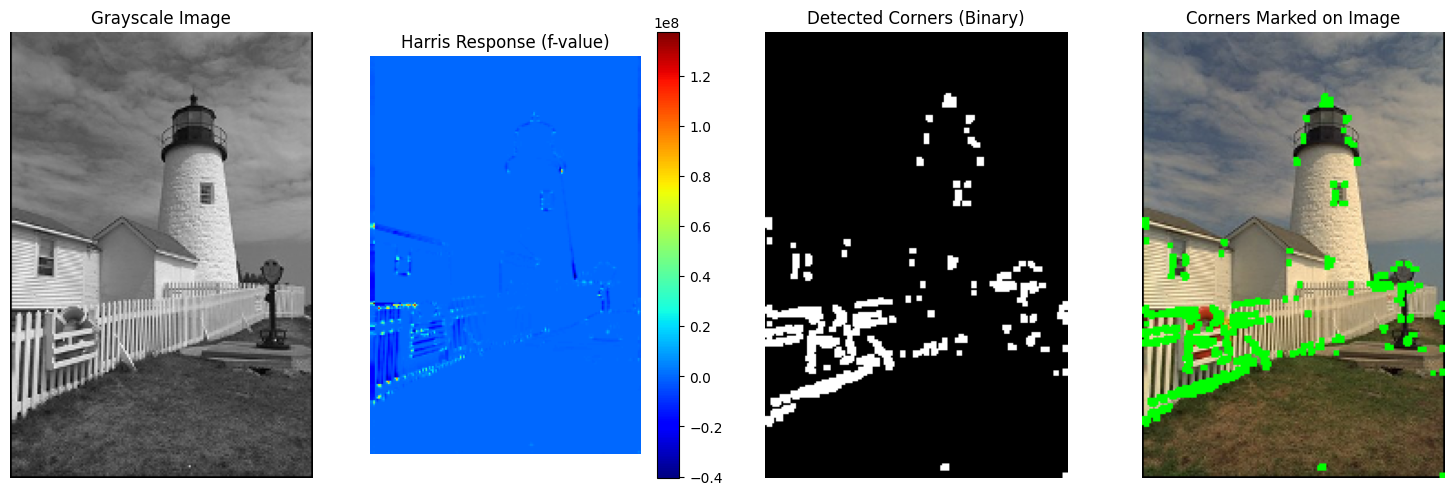

In [5]:
plt.figure(figsize=(15, 5))

# Original Grayscale
plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

# Harris f-value map
plt.subplot(1, 4, 2)
plt.imshow(harris_response, cmap='jet')
plt.title("Harris Response (f-value)")
plt.colorbar()
plt.axis('off')

# Local Maxima Map
plt.subplot(1, 4, 3)
plt.imshow(corners, cmap='gray')
plt.title("Detected Corners (Binary)")
plt.axis('off')

# Final Image with Corners
plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
plt.title("Corners Marked on Image")
plt.axis('off')

plt.tight_layout()
plt.show()